Since there is inconsistency in frame rate accross videos with majority having fps 30, convert all videos to FPS30

In [20]:
import pandas as pd
import json
import cv2
import os
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

!pip install tensorflow



In [ ]:

#Sorry im really bad with pathing
dataset_path=r"C:\Users\65915\Desktop\60.001 Applied Deep Learning\WLASL_v0.3.json"
missing_path=r"C:\Users\65915\Desktop\60.001 Applied Deep Learning\missing.txt"

with open(dataset_path, "r") as f:
    wlasl_data = json.load(f)
with open(missing_path, "r") as f:
    missing_videos = set(f.read().splitlines()) 

#removing missing data & remove instances where there are <4 samples for word
filtered_data = []

for sign in wlasl_data:
    # Remove missing videos
    valid_instances = [inst for inst in sign["instances"] if inst["video_id"] not in missing_videos]
    
    # Only keep glosses with at least 4 valid instances
    if len(valid_instances) >= 4:
        filtered_data.append({
            "gloss": sign["gloss"],
            "instances": valid_instances
        })

print(f"Original dataset size: {len(wlasl_data)}")
print(f"Filtered dataset size (after removing missing and low-instance glosses): {len(filtered_data)}")

filtered_dataset_path = "./WLASL_filtered.json"

with open(filtered_dataset_path, "w") as f:
    json.dump(filtered_data, f, indent=4)

print(f"Filtered dataset saved at: {filtered_dataset_path}")

Original dataset size: 2000
Filtered dataset size (after removing missing and low-instance glosses): 1910
Filtered dataset saved at: ./WLASL_filtered.json


In [2]:
video_directory_path=r"C:\Users\65915\Desktop\60.001 Applied Deep Learning\videos"
filtered_dataset_path = "./WLASL_filtered.json"

with open(filtered_dataset_path, "r") as f:
    wlasl_data = json.load(f)

In [3]:


def preprocess_video(video_path, target_fps=30, target_frames=30, target_size=(112, 112)):
    """
    Process a video for 3D CNN:
    - Resize frames
    - Sample frames to a fixed number
    - Normalize pixel values
    """
    cap = cv2.VideoCapture(video_path)
        # Check if the video can be opened successfully
    if not cap.isOpened():
        print(f"Warning: Cannot open video {video_path}. Skipping.")
        return None
    
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, target_size)  # Resize to target size
        frames.append(frame)

    cap.release()
    
    num_frames = len(frames)
    
    if num_frames == 0:
        print(f"Warning: {video_path} is empty!")
        return None  # Skip empty videos

    # Sample frames uniformly to match target_frames
    frame_indices = np.linspace(0, num_frames - 1, target_frames).astype(int)
    sampled_frames = [frames[i] for i in frame_indices]

    # Convert to NumPy array and normalize to [0,1]
    video_array = np.array(sampled_frames, dtype=np.float32) / 255.0  # Shape: (target_frames, height, width, channels)
    
    return video_array





In [15]:
import numpy as np
import os
import pickle
import cv2
from tqdm import tqdm

save_dir = "./processed_videos"  # Directory to save processed videos
os.makedirs(save_dir, exist_ok=True)  # Create directory if not exists

processed_videos = set(os.listdir(save_dir))  # Track already saved videos

def preprocess_video(video_path, target_fps=30, target_frames=30, target_size=(112, 112)):
    """
    Process a video for 3D CNN:
    - Resize frames
    - Convert to grayscale
    - Sample frames to a fixed number
    - Normalize pixel values
    """
    cap = cv2.VideoCapture(video_path)
    
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Convert the frame to grayscale
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        gray_frame = cv2.resize(gray_frame, target_size)  # Resize to target size
        frames.append(gray_frame)

    cap.release()
    
    num_frames = len(frames)
    
    if num_frames == 0:
        print(f"Warning: {video_path} is empty!")
        return None  # Skip empty videos

    # Sample frames uniformly to match target_frames
    frame_indices = np.linspace(0, num_frames - 1, target_frames).astype(int)
    sampled_frames = [frames[i] for i in frame_indices]

    # Convert to NumPy array and normalize to [0, 1]
    video_array = np.array(sampled_frames, dtype=np.float32) / 255.0  # Shape: (target_frames, height, width)
    
    return video_array



# Process and save one video at a time
for sign in tqdm(wlasl_data, desc="Processing Signs", unit="sign"):
    gloss = sign["gloss"]

    for instance in tqdm(sign["instances"], desc="Processing Instances", unit="instance", leave=False):
        video_id = instance["video_id"]
        save_path = os.path.join(save_dir, f"{video_id}.pkl")

        # Skip if already processed
        if f"{video_id}.pkl" in processed_videos:
            continue  

        video_path = os.path.join(video_directory_path, f"{video_id}.mp4")

        if os.path.exists(video_path):
            processed_video = preprocess_video(video_path)
            if processed_video is not None:
                with open(save_path, "wb") as f:
                    pickle.dump({"video": processed_video, "label": gloss}, f)


Processing Signs: 100%|██████████| 1910/1910 [36:27<00:00,  1.15s/sign] 


Label: abdomen
Video shape: (30, 112, 112)


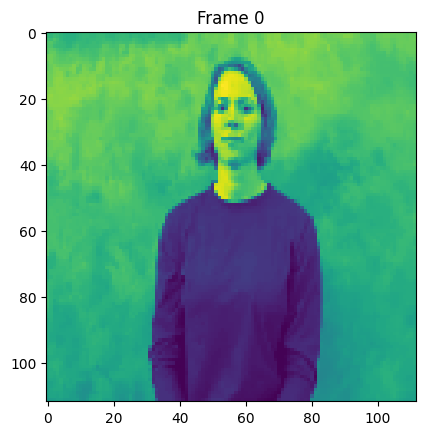

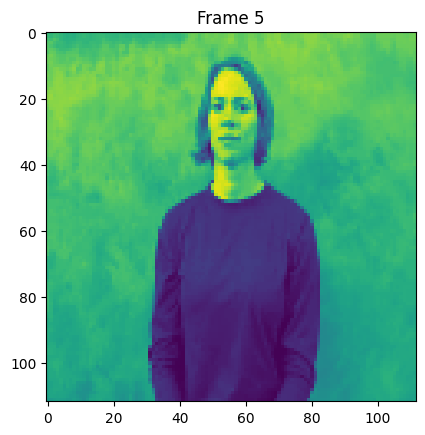

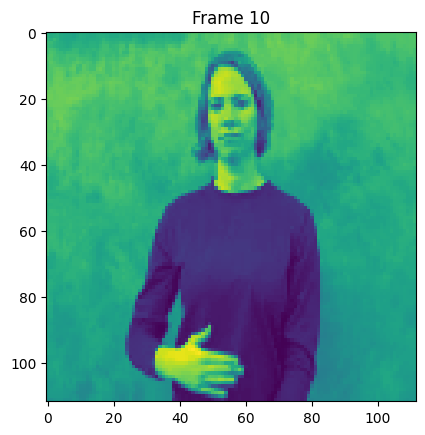

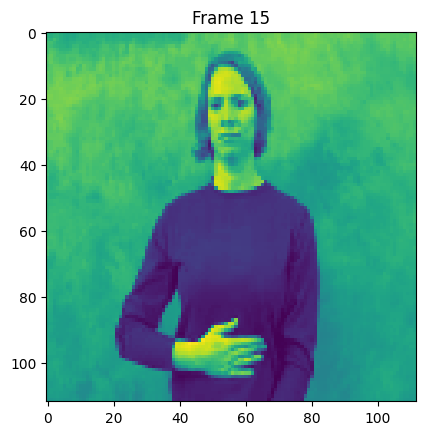

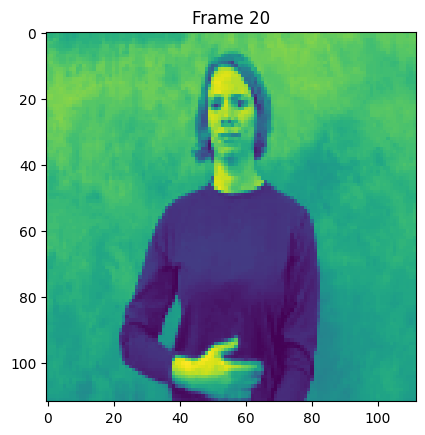

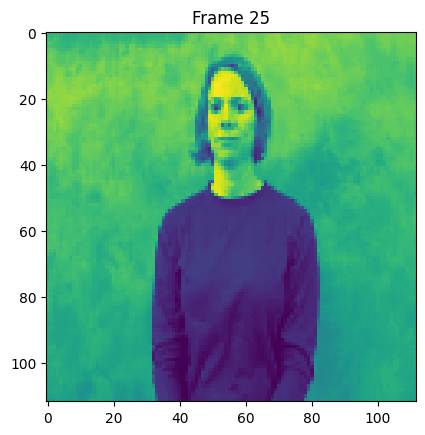

In [ ]:
#Checking 
video_id="00335"
sample_file = "./processed_videos/"+str(video_id)+".pkl"  # Replace with an actual file from your directory

with open(sample_file, "rb") as f:
    data = pickle.load(f)

video_frames = data["video"]
label = data["label"]

print(f"Label: {label}")
print(f"Video shape: {video_frames.shape}")  # Should be (30, 112, 112, 3)

# Display a few frames
for i in range(0, 30, 5):  # Show every 5th frame
    plt.imshow(video_frames[i])  
    plt.title(f"Frame {i}")
    plt.show()


In [43]:
#Currently have processed videos as video_id.pkl files, need to map them to their split and gloss.
#Step 1: create empty dataframe
import pandas as pd
path="./processed_data.csv"
columns = ['video_id','processed_array','split','gloss','label']
empty_df = pd.DataFrame(columns=columns)
empty_df.to_csv(path, index=False)
print(empty_df)

Empty DataFrame
Columns: [video_id, processed_array, split, gloss, label]
Index: []


In [3]:
#Preparing dictionary to map gloss to label
class_list_path="./wlasl_class_list.json"
with open(class_list_path, "r", encoding="utf-8") as f:
    class_list_data = json.load(f)
    gloss_to_label = {entry["gloss"]: entry["label_idx"] for entry in class_list_data}
def get_label_idx(gloss):
    return gloss_to_label.get(gloss, None)  # Returns None if gloss is not found

In [4]:
import os
import json
import pickle
import pandas as pd
from tqdm import tqdm

# Define file paths
final_processed_path = "./processed_data.csv"
array_path = "./processed_videos"
filtered_dataset_path = "./WLASL_filtered.json"
label_list_path="./wlasl_class_list.json"

# Load existing processed data
existing_df = pd.read_csv(final_processed_path)
processed_id = set(existing_df['video_id'].astype(str).tolist())  # Ensure video IDs are unique

# Load JSON data once
with open(filtered_dataset_path, "r", encoding="utf-8") as f:
    data = json.load(f)
with open(label_list_path, "r", encoding="utf-8") as f:
    class_list_data = json.load(f)

# Function to get gloss and split from video_id
def get_gloss_and_split(video_id, data):
    for entry in data:
        gloss = entry["gloss"]
        for instance in entry["instances"]:
            if instance["video_id"] == video_id:
                return {"gloss": gloss, "split": instance["split"]}
    return {"gloss": None, "split": None}  # Return None if video_id not found

# Process pkl files
new_entries = []
pkl_files = [file for file in os.listdir(array_path) if file.endswith(".pkl")]

for file in tqdm(pkl_files, desc="Processing files"):
    video_id = file.replace(".pkl", "").zfill(5)

    if video_id in processed_id:
        print(f"Video has already been saved, skipping {video_id}")
        continue

    file_path = os.path.join(array_path, file)
    with open(file_path, "rb") as f:
        processed_array = pickle.load(f)

    # Get gloss and split info
    info = get_gloss_and_split(video_id, data)
    label=gloss_to_label.get(info["gloss"], None)

    # Store new data
    new_entries.append({
        "video_id": video_id,
        "processed_array": processed_array,
        "gloss": info["gloss"],
        "split": info["split"],
        "label": label
    })

    # Add to processed_id set to avoid future duplicates
    processed_id.add(video_id)

# If there are new entries, update the CSV
if new_entries:
    new_df = pd.DataFrame(new_entries)
    updated_df = pd.concat([existing_df, new_df], ignore_index=True)
    updated_df.to_csv(final_processed_path, index=False)
    print(f"Final Data saved to {final_processed_path}")
else:
    print("No new data to process.")


Processing files: 100%|██████████| 11724/11724 [00:44<00:00, 265.32it/s]


Video has already been saved, skipping 10005
Video has already been saved, skipping 10007
Video has already been saved, skipping 10008
Video has already been saved, skipping 10013
Video has already been saved, skipping 10015
Video has already been saved, skipping 10016
Video has already been saved, skipping 10017
Video has already been saved, skipping 10019
Video has already been saved, skipping 10021
Video has already been saved, skipping 10023
Video has already been saved, skipping 10089
Video has already been saved, skipping 10090
Video has already been saved, skipping 10091
Video has already been saved, skipping 10093
Video has already been saved, skipping 10096
Video has already been saved, skipping 10102
Video has already been saved, skipping 10104
Video has already been saved, skipping 10105
Video has already been saved, skipping 10106
Video has already been saved, skipping 10107
Video has already been saved, skipping 10109
Video has already been saved, skipping 10111
Video has 

In [61]:
df = pd.read_csv("processed_data.csv")
df['video_id'] = df['video_id'].astype(str).str.zfill(5)
df['label'] = df['label'].astype(int)
df.to_csv('processed_data.csv', index=False)
print(df.dtypes)


video_id           object
processed_array    object
split              object
gloss              object
label               int64
dtype: object


In [62]:
existing_df = pd.read_csv('./processed_data.csv')
print(existing_df.dtypes)

video_id            int64
processed_array    object
split              object
gloss              object
label               int64
dtype: object


In [65]:
def get_gloss_and_split(video_id, data):
    for entry in data:
        gloss = entry["gloss"]
        for instance in entry["instances"]:
            if instance["video_id"] == video_id:
                return {"gloss": gloss, "split": instance["split"]}
    return {"gloss": None, "split": None}  # Return None if video_id not found

def verify_data_correctness(df, data,class_list_data):
    errors = []  # List to store any mismatched records

    for _, row in tqdm(df.iterrows(),desc="processing data"):
        video_id = str(row['video_id']).zfill(5)
        gloss = row['gloss']
        split = row['split']
        label = row['label']
    
        # Check if the gloss and split match the expected values for the given video_id, check if label match gloss
        expected_info = get_gloss_and_split(video_id, data)
        excepted_label=gloss_to_label.get(expected_info["gloss"], None)

        if expected_info["gloss"] != gloss:
            errors.append(f"Error in video_id {video_id}: Expected gloss {expected_info['gloss']}, found {gloss}")
        if expected_info["split"] != split:
            errors.append(f"Error in video_id {video_id}: Expected split {expected_info['split']}, found {split}")
        if excepted_label != label:
            errors.append(f"Error in video_id {video_id}: Expected label {excepted_label}, found {label}")
    
    if errors:
        # If there are errors, print them out
        print(f"Verification completed with {len(errors)} errors.")
        for error in errors:
            print(error)
    else:
        print("Verification successful. All data is correct.")

# Example Usage

final_processed_path = "./processed_data.csv"
filtered_dataset_path = "./WLASL_filtered.json"
class_list_path="./wlasl_class_list.json"

existing_df = pd.read_csv(final_processed_path)

with open(filtered_dataset_path, "r", encoding="utf-8") as f:
    data = json.load(f)

with open(class_list_path, "r", encoding="utf-8") as f:
    class_list_data = json.load(f)

verify_data_correctness(existing_df, data,class_list_data)  # Pass the dataframe and loaded JSON data



processing data: 13419it [00:10, 1304.61it/s]

Verification completed with 9 errors.
Error in video_id 34002: Expected label None, found 163
Error in video_id 34004: Expected label None, found 163
Error in video_id 34005: Expected label None, found 163
Error in video_id 34006: Expected label None, found 163
Error in video_id 34007: Expected label None, found 163
Error in video_id 34008: Expected label None, found 163
Error in video_id 34012: Expected label None, found 163
Error in video_id 34017: Expected label None, found 163
Error in video_id 34018: Expected label None, found 163


Data preprocessing has been completed, do 3DCNN

In [75]:
#Prepare Datasets
def create_dataset(df, batch_size=32):
    # Generator function to yield video and label pairs
    def generator():
        for _, row in df.iterrows():
            print(type(row['processed_array']))
            video = row['processed_array']['video']  # This should be a numpy array of shape (num_frames, height, width, channels)
            label = row['label']  # Integer label (0-1999)

            yield video, label
    dataset = tf.data.Dataset.from_generator(generator, output_signature=(
        tf.TensorSpec(shape=(30, 112, 112, 1), dtype=tf.float32),  # Shape of the video frames
        tf.TensorSpec(shape=(), dtype=tf.int32)  # Integer label
    ))
    dataset = dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

df=pd.read_csv("./processed_data.csv")
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'validation']
test_df = df[df['split'] == 'test']

train_dataset = create_dataset(train_df)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

for video_batch, label_batch in train_dataset.take(1):
    print(video_batch.shape)  # Should be (batch_size, 32, 224, 224, 3) if num_frames = 32 and image size = 224x224
    print(label_batch.shape)  # Should be (batch_size,)

<class 'str'>


InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} TypeError: string indices must be integers, not 'str'
Traceback (most recent call last):

  File "c:\Python312\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "c:\Python312\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "c:\Python312\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\65915\AppData\Local\Temp\ipykernel_12492\1592203823.py", line 7, in generator
    video = row['processed_array']['video']  # This should be a numpy array of shape (num_frames, height, width, channels)
  

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, Model

# Load base model (without the classification layer)
base_model = hub.KerasLayer("https://tfhub.dev/deepmind/i3d-kinetics-400/1", trainable=True)





# Define new model
inputs = tf.keras.Input(shape=)  
x = base_model(inputs)  # Extract features
x = layers.Dense(256, activation='relu')(x)  # Add a Dense layer
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2000, activation='softmax')(x)  # 20 sign language classes

# Create new model
model = Model(inputs, outputs)

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary
model.summary()


NameError: name 'hub' is not defined